## Project Summary

**This project is owned by Nick Pandolfi and Will Wang.**

**Summary:** The notebook is a Bayesian Marketing Mix Modeling project. It uses the pymc-marketing library to analyze how different advertising channels (like TV, Facebook, and Radio) impact bike sales. We use the [PyMC-Marketing](https://www.pymc-marketing.io/en/stable/) Library as our primary solution

**Dataset:** A fictitious dataset that contains 5 years worth of "bike sales" and historical marketing spends from [Kaggle](https://www.kaggle.com/datasets/mattwalentosky/mmmdemodataset/data)

**Industry Context:** Media Mix Model's are the single most popular source of Sales measurement in Advertising. They are the anchor for Ad Investment decision making that allow advertisers the ability to optimize budget allocations to maximize performance. Understanding  the complexities of MMM's is a significant value add as a marketing data scientist to help drive business growth.

### Approach

### Imports

We start by installing all necessary packages

In [2]:
!pip install pymc-marketing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.4/461.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.3/263.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.6 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [3]:
# @title
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import warnings

import arviz as az
import matplotlib.pyplot as plt
import pymc as pm
import seaborn as sns

from pymc_extras.prior import Prior
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

The dataset is stored in Google Drive (vs uploaded to colab) for persistence

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Courses/Bayesian ML/Final Project: MMM/bike_sales_data.csv')

## Exporatory Data Analysis

We start by evaluating a sample of the dataset

In [6]:
df.head()

,Week,sales,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend,ooh_spend,tv_spend,radio_spend
0,7/23/17,58850.0,1528.8,463.32,802.620,0,0,0,0
1,7/30/17,62050.0,1575.6,468.00,819.312,0,0,0,0
2,8/6/17,59388.0,1544.4,477.36,749.034,0,0,0,0
3,8/13/17,56964.0,1528.8,468.00,741.468,0,0,0,0
4,8/20/17,53460.0,1560.0,458.64,811.200,0,0,0,0


In [7]:
df.sum()

,0
Week,7/23/177/30/178/6/178/13/178/20/178/27/179/3/1...
sales,17707963.9252
branded_search_spend,528756.86
nonbranded_search_spend,104619.7725
facebook_spend,263968.3273
print_spend,98000
ooh_spend,49000
tv_spend,72500
radio_spend,136000


### Capture Channels

MMM's require us to continuously input the Media Channels. We capture the channels below to make an easier workflow throughout the notebook

In [8]:
df.columns

Index(['Week', 'sales', 'branded_search_spend', 'nonbranded_search_spend',
       'facebook_spend', 'print_spend', 'ooh_spend', 'tv_spend',
       'radio_spend'],
      dtype='object')

In [9]:
channels = ['branded_search_spend', 'nonbranded_search_spend',
       'facebook_spend', 'print_spend', 'ooh_spend', 'tv_spend',
       'radio_spend']

### Plot Spend & Sales Over Time

Some channels like Search & Facebook are "always on", while channels like Print, Out of Home (Billboards, etc), and TV are on & off consistently

/tmp/ipykernel_233/1993112281.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


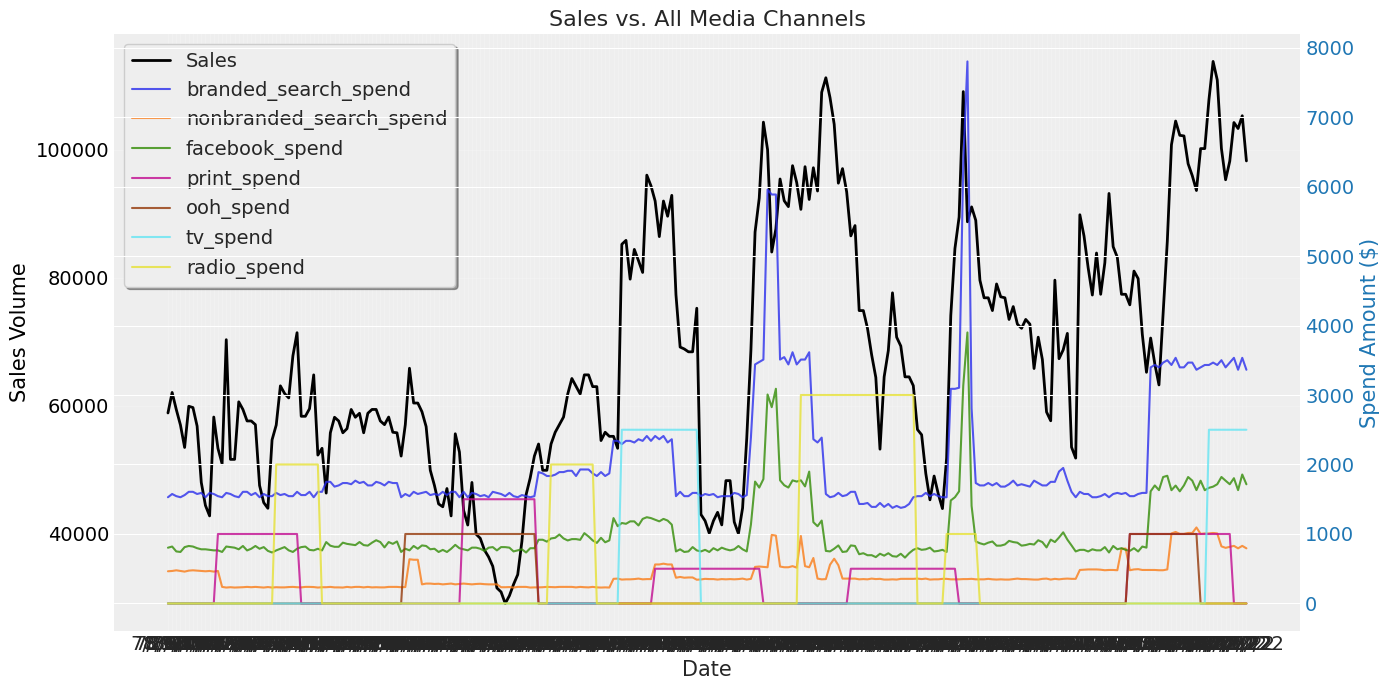

In [10]:
import matplotlib.pyplot as plt

# Setup the figure and the first axis (Sales)
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Sales (Left Axis)
ax1.plot(df['Week'], df['sales'], color='black', linewidth=2, label='Sales', alpha=1)
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales Volume', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Setup the second axis (Spend)
ax2 = ax1.twinx()

# Plot all channels from your "channels" list (Right Axis)
for channel in channels:
    ax2.plot(df['Week'], df[channel], label=channel, alpha=0.8)

ax2.set_ylabel('Spend Amount ($)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Add Title and a combined Legend
plt.title('Sales vs. All Media Channels', fontsize=16)

# merge the legends from both axes into one box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# loc='upper left' puts it inside the plot area
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, shadow=True)

ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Total Spend by Channel

This gives us an idea of what Channels our Bike company invests in the most/least

/tmp/ipykernel_233/1209818852.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


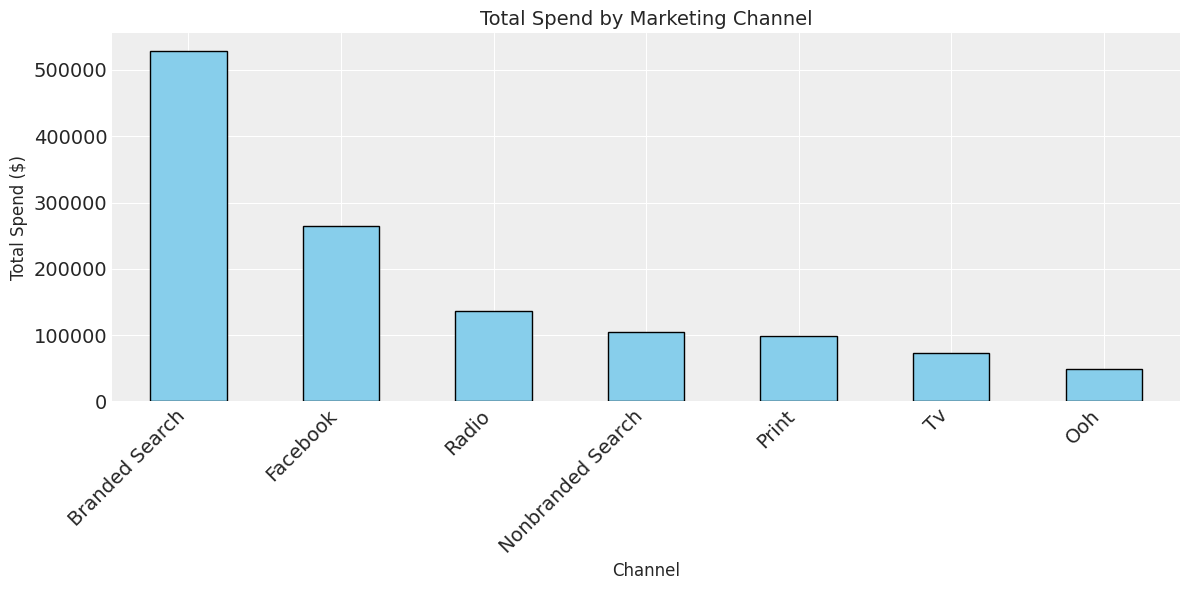

In [11]:
# Sum the spend for each column and sort them from highest to lowest
total_spend = df[channels].sum().sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 6))
total_spend.plot(kind='bar', color='skyblue', edgecolor='black')

# Formatting the chart
plt.title('Total Spend by Marketing Channel', fontsize=14)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Total Spend ($)', fontsize=12)

# Clean up the x-axis labels (remove '_spend' and capitalize)
labels = [label.replace('_spend', '').replace('_', ' ').title() for label in total_spend.index]
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('total_spend_by_channel.png')
plt.show()

## MMM Design

After having an idea of the seasonlity, investment cadence, and general idea of our dataset, we can move into designing our Media Mix Model

We use the following for our model inputs:
*   **Geometric Adstock:** This represents the idea that an ad seen today still has some influence next week, though the effect decays over time.

*   **Logistic Saturation:** This models the "diminishing returns" of advertising—meaning that spending the first $1,000 on Facebook usually has a bigger impact than spending the millionth dollar.

### Initialize

In [12]:
mmm = MMM(
    date_column="Week",
    channel_columns=channels,
    target_column="sales", # Specify the target column name
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)

### Fit

Running mmm.fit() engages the Bayesian Sampler, that estimates the effectiveness of each channel by running thousands of simulated scenarios via Markov Chain Monte Carlo.

This produces a full probability distribution for every parameter, such as the impact of TV ads or the rate of Facebook ad decay. By running multiple independent "chains", the sampler ensures that the results are statistically stable and consistent, allowing the model to account for uncertainty while identifying the most likely relationship between ad spend and bike sales.

In [13]:
# Create X, y
X = df[channels + ["Week"]]
y = df["sales"]

# This will run the Bayesian sampler
mmm.fit(X, y, chains=2, draws=1000)

/usr/local/lib/python3.12/dist-packages/pymc_marketing/mmm/multidimensional.py:1870: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  value=pd.to_datetime(


Output()

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data
	> fit_data

### Visualize Results

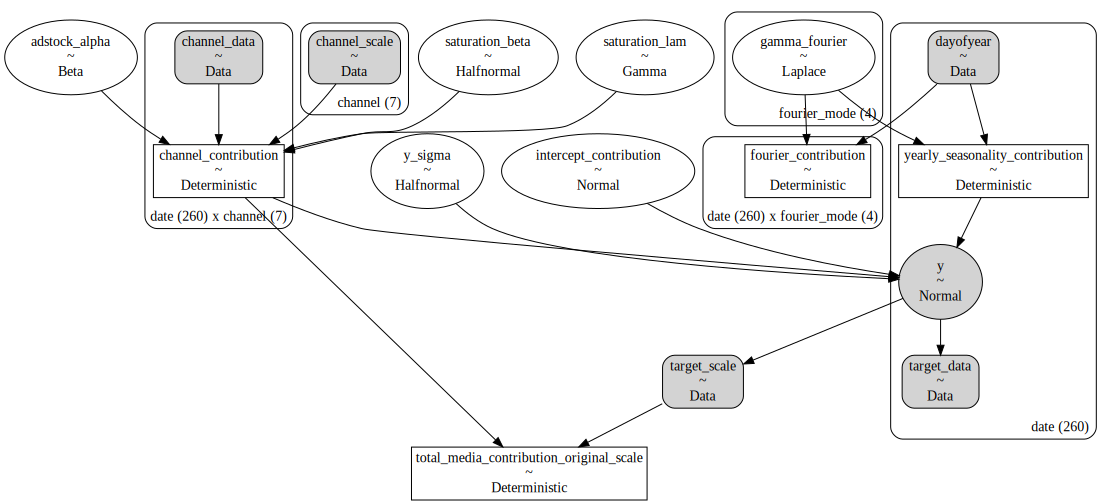

In [14]:
pm.model_to_graphviz(mmm.model)

This code generates and visualizes 2,000 "pre-data" simulations to check if our initial assumptions (priors) about marketing impact are realistic before the model actually looks at the observed sales data.

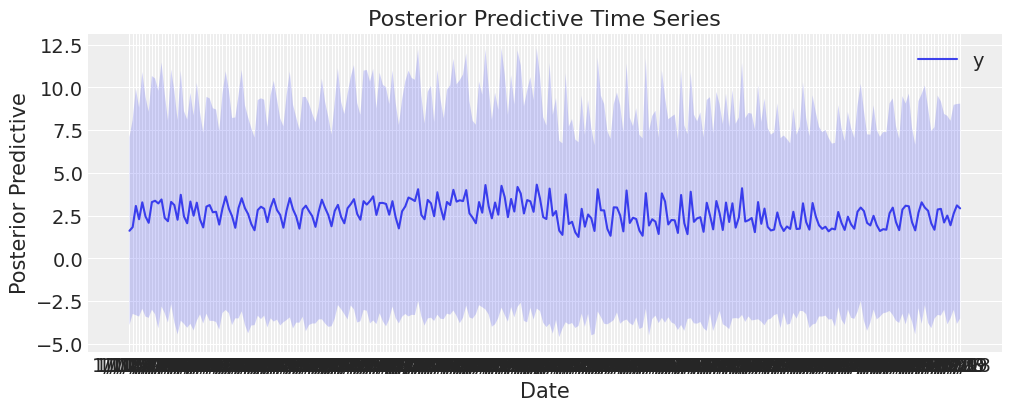

In [15]:
# Generate prior predictive samples
mmm.sample_prior_predictive(X, y, samples=2_000)
fig, axes = mmm.plot.prior_predictive()

### Model Diagnostics

After building our model, we can inspect the learnings below.

The MMM.fit_result is a posterior dataset that stores the "learned" results of our model, acting as a multidimensional map of how marketing spend translates into sales.

It tracks the performance of our 7 measured channels (such as branded search, TV, and Facebook) and provides the channel_contribution, which breaks down the specific sales volume attributed to each individual channel for every week in the 260-week dataset.

A critical output is the total_media_contribution_original_scale, representing the total estimated sales driven by all marketing activities

Additionally, the object contains the posterior distributions for adstock_alpha (how long ad effects last) and saturation_lam (where spending hits diminishing returns), as well as the intercept_contribution and yearly_seasonality_contribution, which reveal the baseline sales we would have received without any advertising and how much seasonal trends influenced our bottom line.

In [16]:
# Number of diverging samples
mmm.idata["sample_stats"]["diverging"].sum().item()

0

In [17]:
mmm.fit_result

<xarray.Dataset> Size: 50MB
Dimensions:                                  (chain: 2, draw: 1000,
                                              fourier_mode: 4, date: 260,
                                              channel: 7)
Coordinates:
  * chain                                    (chain) int64 16B 0 1
  * draw                                     (draw) int64 8kB 0 1 2 ... 998 999
  * fourier_mode                             (fourier_mode) <U5 80B 'sin_1' ....
  * date                                     (date) <U8 8kB '1/10/21' ... '9/...
  * channel                                  (channel) <U23 644B 'branded_sea...
Data variables:
    adstock_alpha                            (chain, draw) float64 16kB 0.010...
    gamma_fourier                            (chain, draw, fourier_mode) float64 64kB ...
    intercept_contribution                   (chain, draw) float64 16kB 0.238...
    saturation_beta                          (chain, draw) float64 16kB 0.131...
    saturation_lam                           (chain, draw) float64 16kB 5.28 ...
    y_sigma                                  (chain, draw) float64 16kB 0.136...
    channel_contribution                     (chain, draw, date, channel) float64 29MB ...
    fourier_contribution                     (chain, draw, date, fourier_mode) float64 17MB ...
    total_media_contribution_original_scale  (chain, draw) float64 16kB 1.061...
    yearly_seasonality_contribution          (chain, draw, date) float64 4MB ...
Attributes:
    created_at:                 2026-03-02T18:28:25.481847+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.0
    sampling_time:              65.17398309707642
    tuning_steps:               1000
    pymc_marketing_version:     0.18.2

The below generates a statistical summary table that provides the mean values, uncertainty intervals, and convergence diagnostics for the model's core parameters, including ad decay rates, saturation effects, and baseline sales.

The output confirms that our model is statistically healthy. The output allows us to evaluate:
*   Model Reliability
*   Marketing Parameters

Statistical diagnostics (R-hat 1.00, high ESS) confirm model convergence.

Key findings: 31% of sales are baseline (intercept), and the low adstock alpha (0.039) indicates that marketing impact is immediate with very little week-over-week carryover.



In [18]:
az.summary(
    data=mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
adstock_alpha,0.039,0.031,0.000,0.096,0.001,0.001,1719.0,977.0,1.0
gamma_fourier[sin_1],-0.027,0.012,-0.050,-0.005,0.000,0.000,1770.0,1366.0,1.0
gamma_fourier[sin_2],-0.051,0.011,-0.071,-0.030,0.000,0.000,1603.0,1359.0,1.0
gamma_fourier[cos_1],-0.127,0.012,-0.151,-0.104,0.000,0.000,1628.0,1505.0,1.0
gamma_fourier[cos_2],-0.018,0.011,-0.039,0.003,0.000,0.000,1854.0,1580.0,1.0
intercept_contribution,0.313,0.037,0.238,0.376,0.001,0.001,833.0,1224.0,1.0
saturation_beta,0.117,0.012,0.095,0.139,0.000,0.000,1161.0,1340.0,1.0
saturation_lam,4.287,0.721,2.942,5.614,0.020,0.015,1336.0,1237.0,1.0
y_sigma,0.132,0.006,0.121,0.143,0.000,0.000,1788.0,1477.0,1.0


Now we generate a Trace Plot as the primary visual diagnostic tool to confirm that our model converged. It shows two things for each parameter: the Posterior Density (left) and the Sampling Trace (right)

Overall, our model looks like it has converged well based on the "fuzzy caterpillar" look in the right-hand plots is exactly what we want to see.


*   **adstock_alpha:** This represents the "memory effect" or decay rate of advertising.
*   **gamma_fourier:** These capture seasonality (likely weekly or yearly cycles).
*   **intercept contribution:** baseline sales without any marketing contribution.
*   **saturation beta/lambda:** Controls the scale/weight of the marketing channel and Diminishing Return.
*   **y_sigma:** white noise/unexplained variance


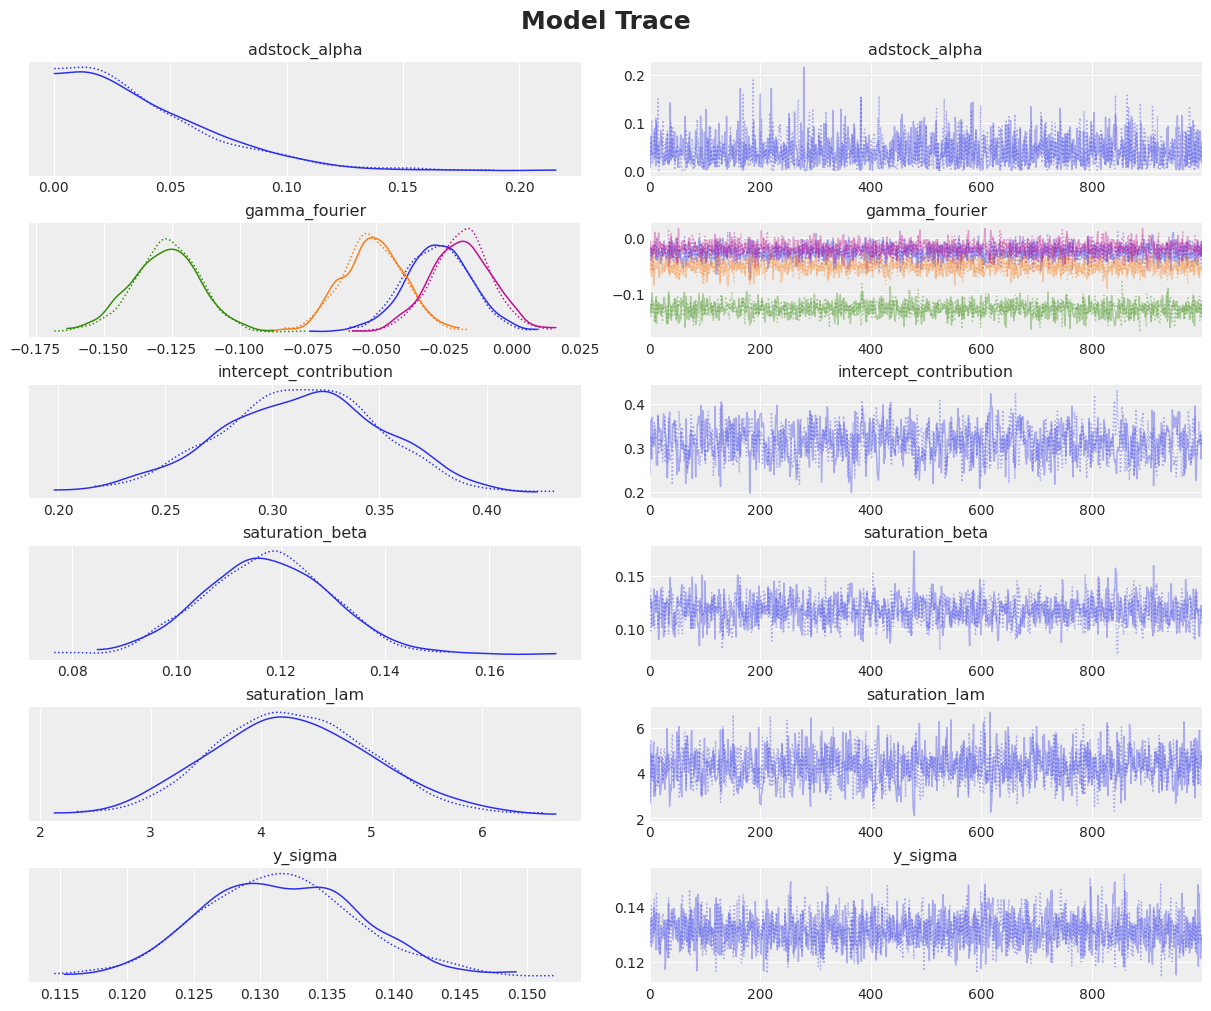

In [19]:
_ = az.plot_trace(
    data=mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=18, fontweight="bold");

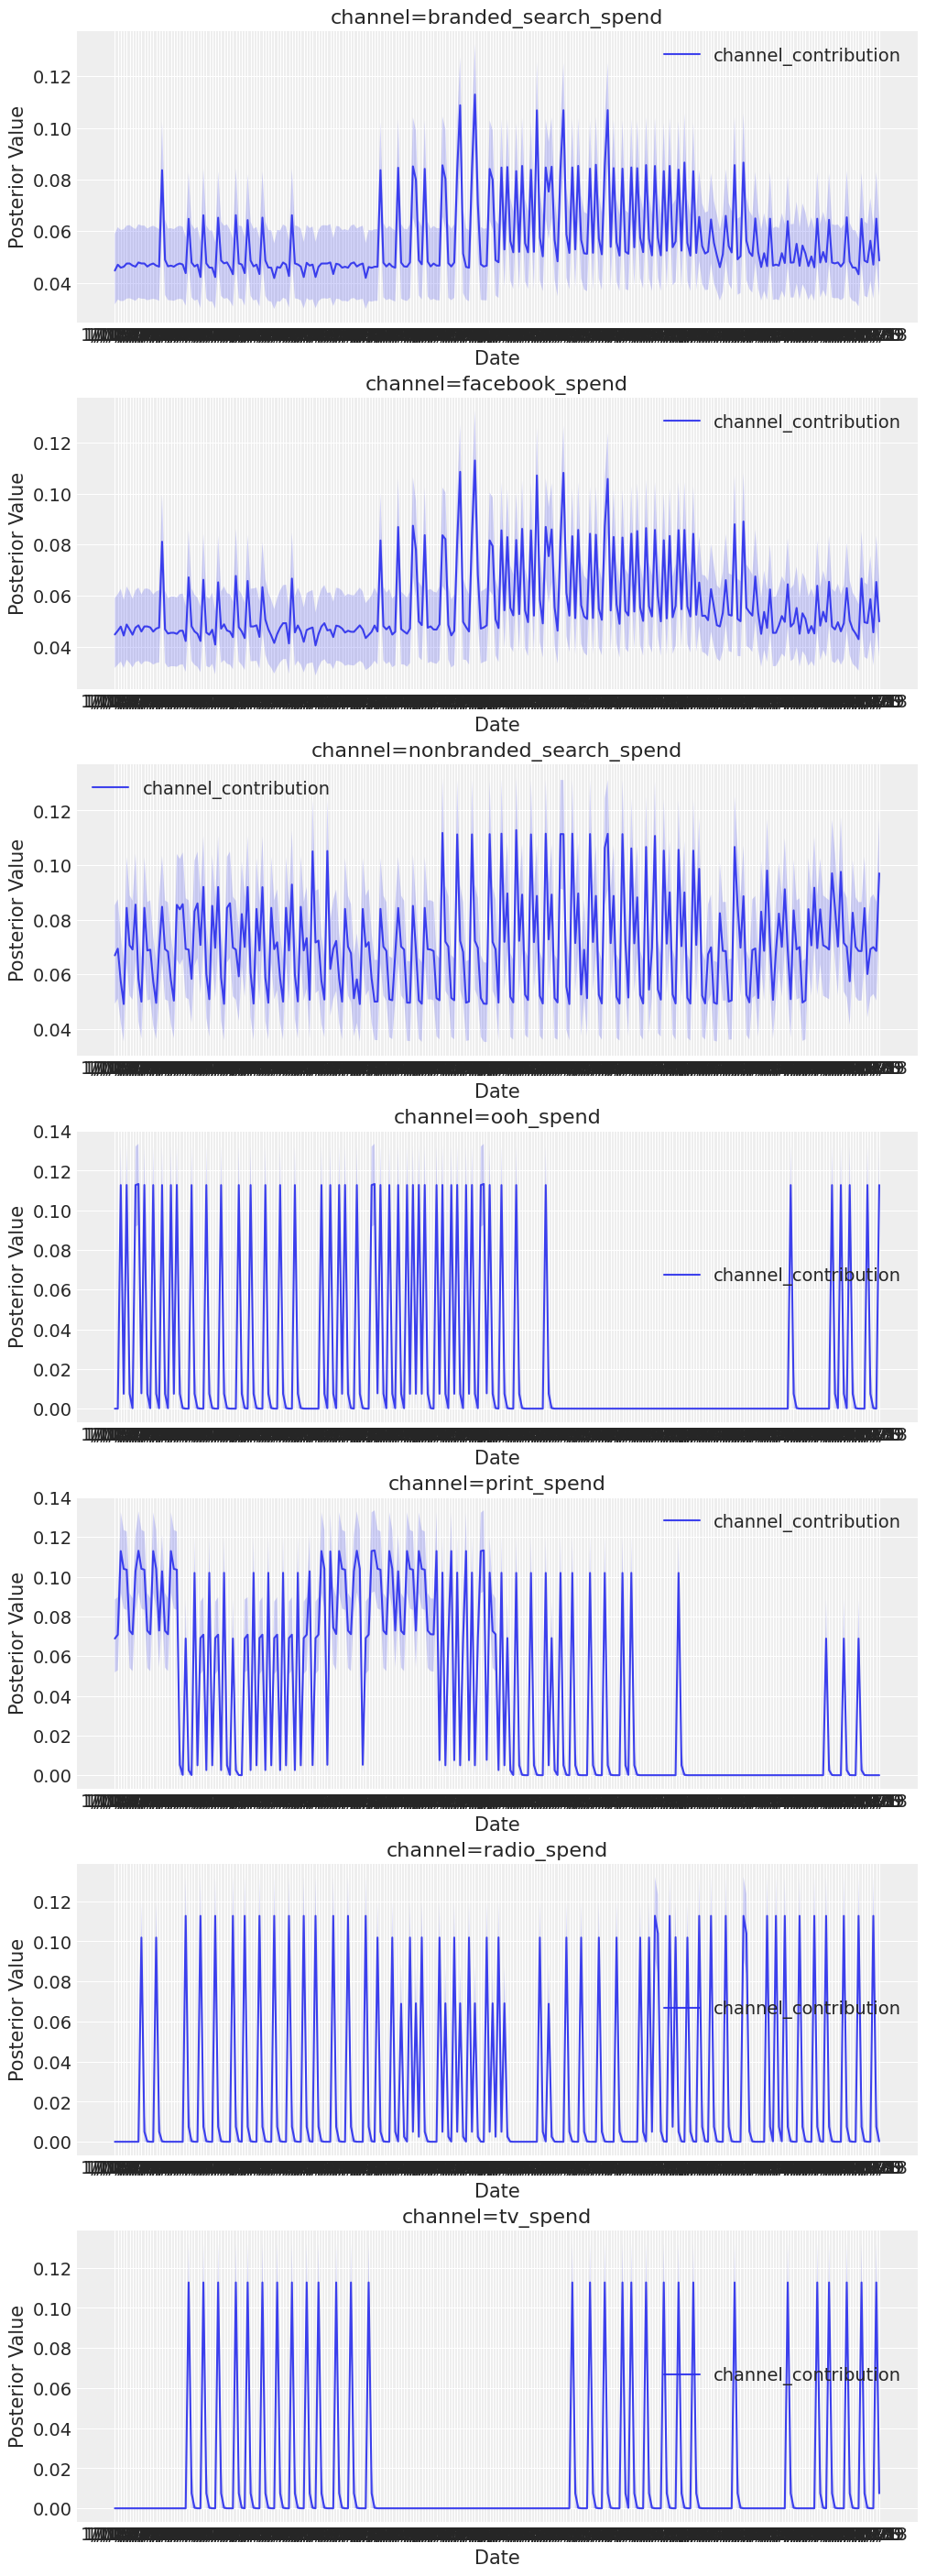

In [20]:
# Component contributions (scaled space)
fig, axes = mmm.plot.contributions_over_time(
    var=["channel_contribution"], hdi_prob=0.94
)

Below we run a sensitivity analysis to see diminshing returns by channel.

Nonbranded search spend represents our most impactful lever with the highest marginal return at the baseline, while traditional channels like TV and radio appear to be nearing saturation with significantly lower total contribution.

**This could point to the hypothesis that when consumers search for "Bike" (non-branded search), they don't have a brand in mind, but they are actively shopping for a bike. Whereas TV or Radio are reaching users not in the market for a bike**

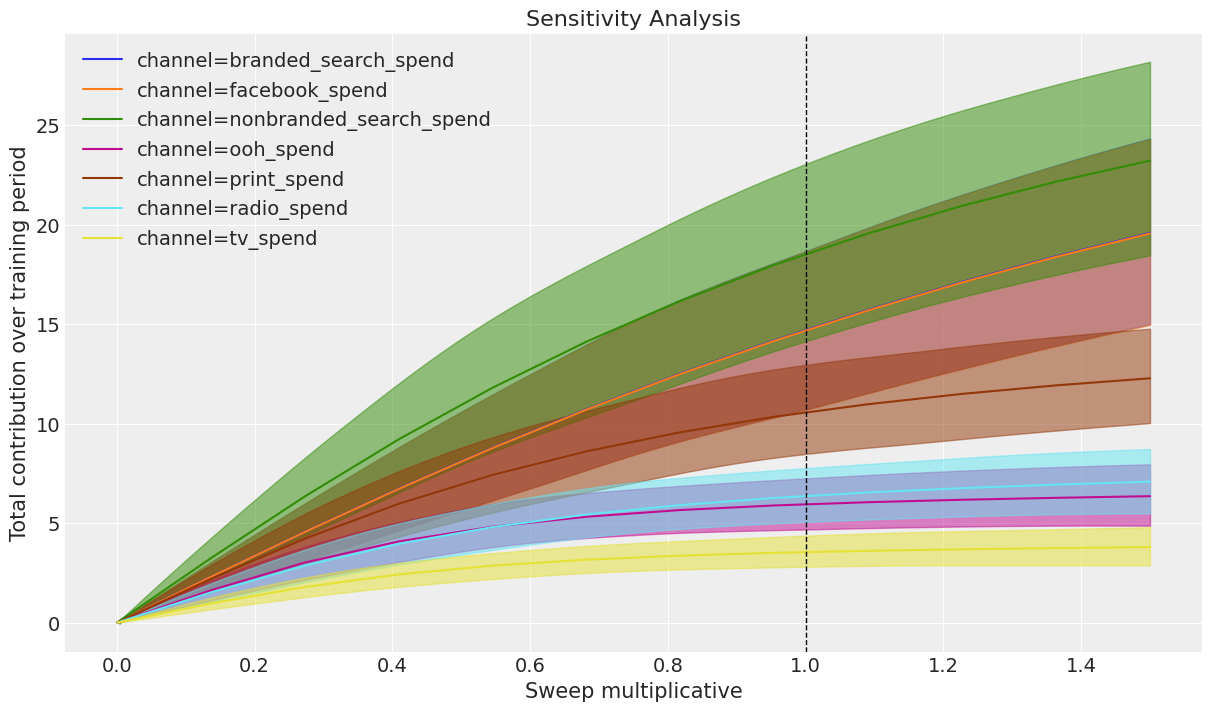

In [21]:
# Run sensitivity analysis sweep
sweeps = np.linspace(0, 1.5, 12)
mmm.sensitivity.run_sweep(
    sweep_values=sweeps,
    var_input="channel_data",
    var_names="channel_contribution",
    extend_idata=True,
)

# Plot sensitivity analysis
ax = mmm.plot.sensitivity_analysis(
    xlabel="Sweep multiplicative",
    ylabel="Total contribution over training period",
    hue_dim="channel",
    x_sweep_axis="relative",
)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1);

The below waterfall chart shows that nonbranded search is our single largest driver of performance, accounting for nearly a quarter of our total sales, while TV and OOH remain our least impactful channels.

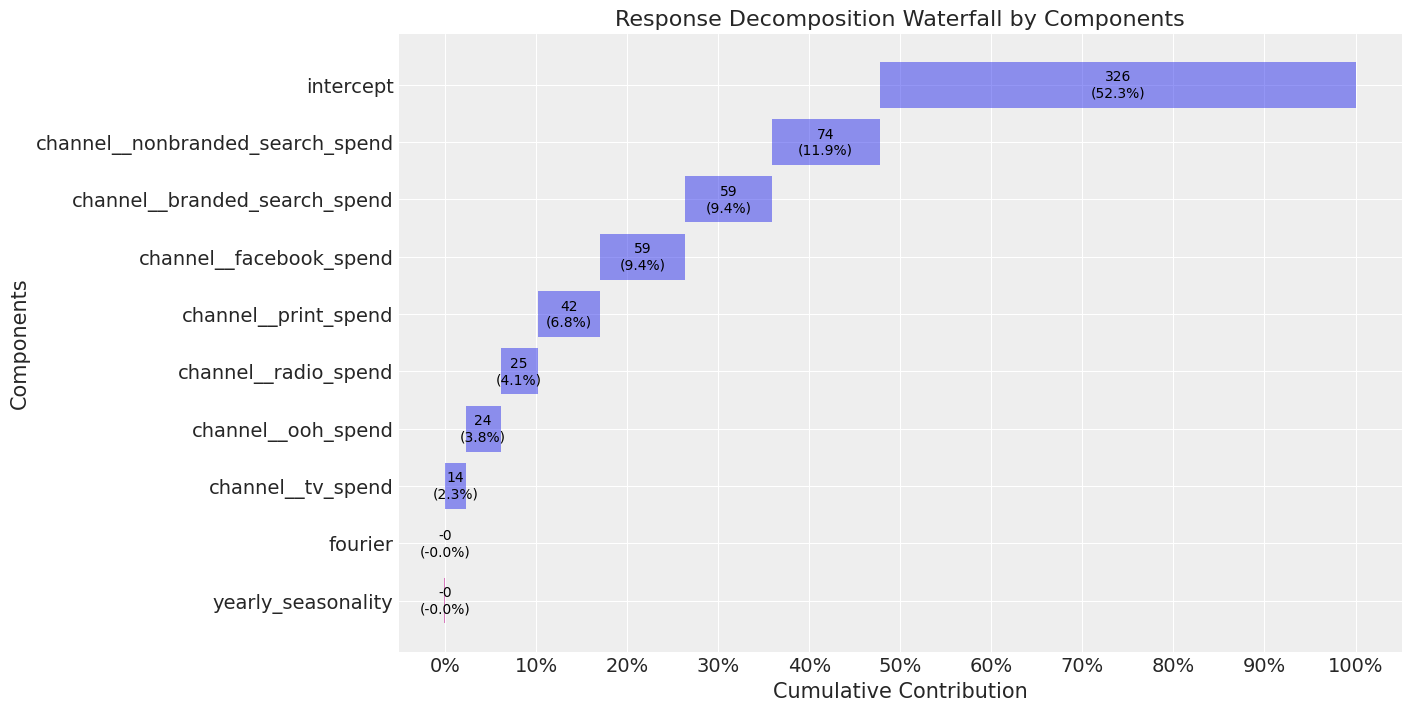

In [22]:
mmm.plot.waterfall_components_decomposition();

Our ROAS output reveals that nonbranded search is our most efficient growth engine, returning $20.18 for every dollar spent, while branded search and radio currently sit at the bottom of our efficiency curve.

This analysis serves as our primary decision-making tool because it provides a standardized benchmark to mathematically justify shifting budget away from low-return channels toward those with the highest marginal impact, ensuring we maximize total revenue for every dollar of our marketing investment.

ROAS Analysis by Channel:
                         Total Attributed Sales  Total Spend       ROAS
nonbranded_search_spend            2.107871e+06  104619.7725  20.147922
ooh_spend                          6.769091e+05   49000.0000  13.814471
print_spend                        1.202698e+06   98000.0000  12.272428
facebook_spend                     1.670894e+06  263968.3273   6.329903
tv_spend                           4.033941e+05   72500.0000   5.564056
radio_spend                        7.242982e+05  136000.0000   5.325722
branded_search_spend               1.673482e+06  528756.8600   3.164936


/tmp/ipykernel_233/1818723187.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


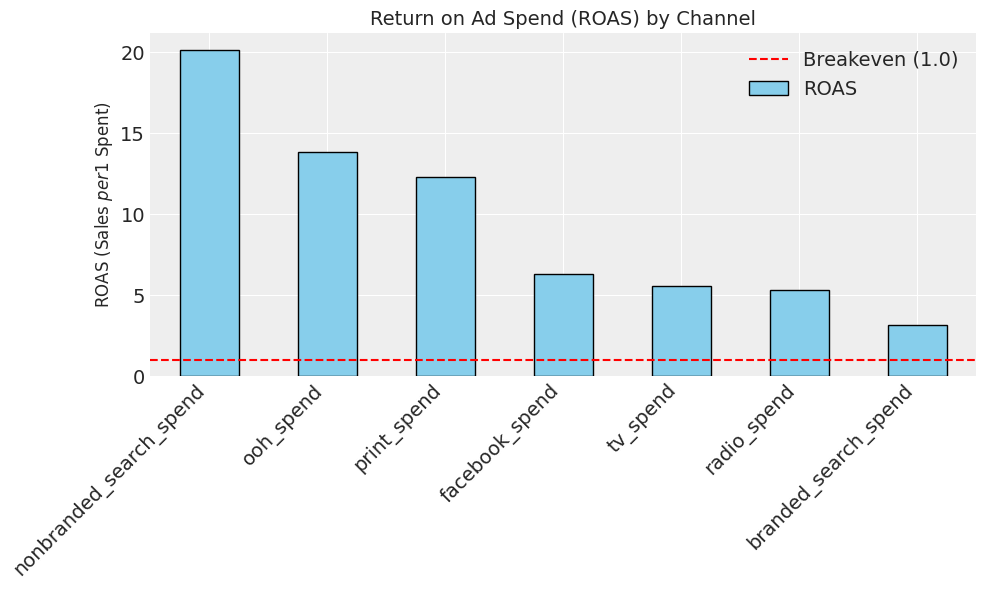

In [23]:
# Access the scaled channel contribution from the posterior results
# Dimensions are (chain, draw, date, channel)
channel_contrib_scaled = mmm.idata.posterior["channel_contribution"]

# Get the target scale factor (the multiplier to go from 0-1 back to actual Sales)
# In Multidimensional MMM, this is stored in the .scalers dictionary
target_scale = mmm.scalers["_target"]

# Unscale the contribution to get real sales values
channel_contrib_original = channel_contrib_scaled * target_scale

# Calculate total sales attributed to each channel
# We sum across the 'date' dimension for every posterior sample
total_attributed_sales_samples = channel_contrib_original.sum(dim="date")

# Take the average across all samples (chains and draws)
mean_attributed_sales = total_attributed_sales_samples.mean(dim=["chain", "draw"]).to_series()

# Get total spend for each channel from your original dataframe
# (Using the 'channels' list you defined earlier)
total_spend = df[channels].sum()

# Final ROAS Calculation: Attributed Sales / Total Spend
roas_df = pd.DataFrame({
    "Total Attributed Sales": mean_attributed_sales,
    "Total Spend": total_spend,
    "ROAS": mean_attributed_sales / total_spend
}).sort_values("ROAS", ascending=False)

# Display the results
print("ROAS Analysis by Channel:")
print(roas_df)

# Visualize the ROAS
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
roas_df['ROAS'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.axhline(1, color='red', linestyle='--', label='Breakeven (1.0)')
plt.title('Return on Ad Spend (ROAS) by Channel', fontsize=14)
plt.ylabel('ROAS (Sales $ per $1 Spent)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()